<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/K_NearestNeighbors_breastcancerprediction%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# A. Load Dataset

dataset = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/wisconsin_data-02.csv')
dataset

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


In [ ]:
# B. Append validation data

validation_data = [
    [2.68, 23.84, 82.69, 499, 0.1122, 0.1262, 0.1128, 0.06873, 0.1905, 0.0659, 0.4255, 1.178, 2.927, 36.46, 0.007781,
     0.02648, 0.02973, 0.0129, 0.01635, 0.003601, 17.09, 33.47, 111.8, 888.3, 0.1851, 0.4061, 0.4024, 0.1716, 0.3383, 0.103, 'Unknown'],
    [3.08, 15.71, 85.63, 520, 0.1075, 0.127, 0.04568, 0.0311, 0.1967, 0.06811, 0.1852, 0.7477, 1.383, 14.67, 0.004097,
     0.01898, 0.01698, 0.00649, 0.01678, 0.002425, 14.5, 20.49, 96.09, 630.5, 0.1312, 0.2776, 0.189, 0.07283, 0.3184, 0.0818, 'Unknown']
]
validation_df = pd.DataFrame(validation_data, columns=dataset.columns)
full_dataset = pd.concat([dataset, validation_df], ignore_index=True)
full_dataset

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.26540,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.18600,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.24300,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.25750,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.16250,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820,M
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400,M
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039,B
569,2.68,23.84,82.69,499.0,0.11220,0.12620,0.11280,0.06873,0.1905,0.06590,...,33.47,111.80,888.3,0.18510,0.40610,0.4024,0.17160,0.3383,0.10300,Unknown


In [ ]:
# C. Normalize the dataset using StandardScaler

scaler = StandardScaler()
features = full_dataset.drop('diagnosis', axis=1)
features_scaled = scaler.fit_transform(features)
normalized_df = pd.DataFrame(features_scaled, columns=features.columns)
normalized_df['diagnosis'] = full_dataset['diagnosis'].values
normalized_df


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,1.090869,-2.074066,1.273053,0.987257,1.565251,3.286776,2.657057,2.535780,2.218964,2.256113,...,-1.359651,2.307731,2.005159,1.299935,2.617114,2.111815,2.297366,2.751308,1.936854,M
1,1.812132,-0.354085,1.689727,1.912935,-0.830403,-0.489255,-0.023459,0.548789,-0.000198,-0.871690,...,-0.369842,1.537994,1.894235,-0.378466,-0.432793,-0.147331,1.087481,-0.246314,0.279763,M
2,1.566120,0.455865,1.570088,1.562602,0.938936,1.052966,1.365833,2.039871,0.939381,-0.400533,...,-0.024710,1.350035,1.459342,0.521926,1.081973,0.855666,1.956038,1.151280,0.199903,M
3,-0.745835,0.253378,-0.592488,-0.764125,3.280499,3.406342,1.919035,1.453563,2.869724,4.914177,...,0.133203,-0.250003,-0.550146,3.380453,3.895019,1.991725,2.176987,6.050149,4.937143,M
4,1.733856,-1.152399,1.780487,1.830336,0.277035,0.538639,1.373377,1.430317,-0.011166,-0.565154,...,-1.467098,1.341084,1.223408,0.215968,-0.315636,0.613564,0.729392,-0.871426,-0.399046,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,0.702282,2.045509,0.674859,0.580244,-0.843926,-0.040215,0.047075,0.105829,-0.811820,-0.898654,...,1.373722,0.580298,0.429332,-0.811179,0.349104,0.326787,0.413968,-1.107867,-0.320295,M
567,1.820519,2.336440,1.986761,1.739192,1.522548,3.275388,3.302041,2.662339,2.138533,1.042741,...,2.236549,2.307731,1.656540,1.422318,3.906480,3.201278,2.291270,1.918905,2.219691,M
568,-1.769022,1.221594,-1.816105,-1.348299,-3.115740,-1.153894,-1.116033,-1.263601,-0.822788,-0.563735,...,0.763230,-1.434742,-1.076772,-1.857557,-1.210615,-1.307888,-1.746758,-0.050359,-0.753423,B
569,-3.189184,1.058673,-0.381676,-0.442559,1.123984,0.413379,0.302176,0.511596,0.339805,0.438184,...,1.267903,0.135760,0.014334,2.300857,0.964816,0.625092,0.868056,0.778805,1.055069,Unknown


In [ ]:
# E. Remove validation data before training
train_data = normalized_df[normalized_df['diagnosis'] != 'Unknown']
X = train_data.drop('diagnosis', axis=1)
y = train_data['diagnosis']

X_val = normalized_df[normalized_df['diagnosis'] == 'Unknown'].drop(columns='diagnosis')
X_val = pd.DataFrame(X_val, columns=X.columns)

In [ ]:
# F. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

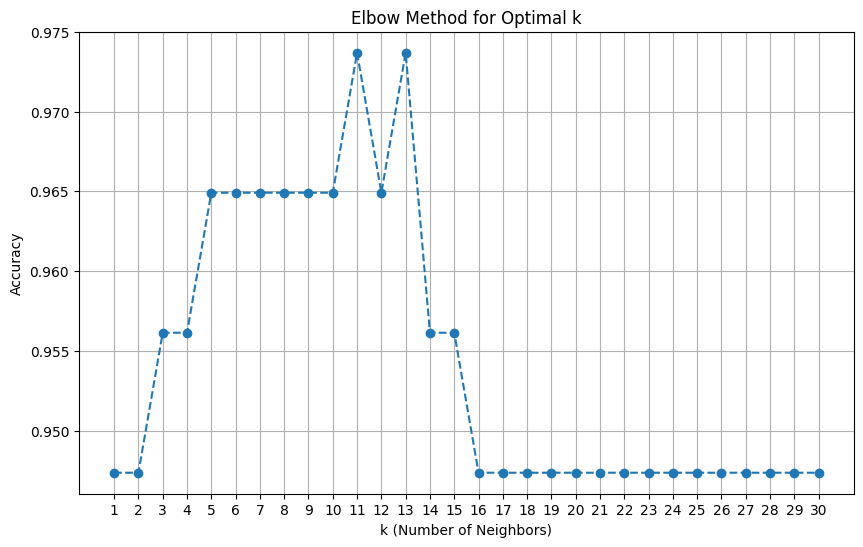

Optimized k-value : 11
Model's accuracy: 0.9737


In [ ]:
# Find best k using Elbow Method: test k from 1 to 30
k_range = range(1, 31)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)

# Plot the Elbow Curve
plt.figure(figsize=(10,6))
plt.plot(k_range, accuracies, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(k_range)
plt.show()

best_k = k_range[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)

# Train final model with best_k
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)

print(f"Optimized k-value : {best_k}")
print(f"Model's accuracy: {best_accuracy:.4f}")

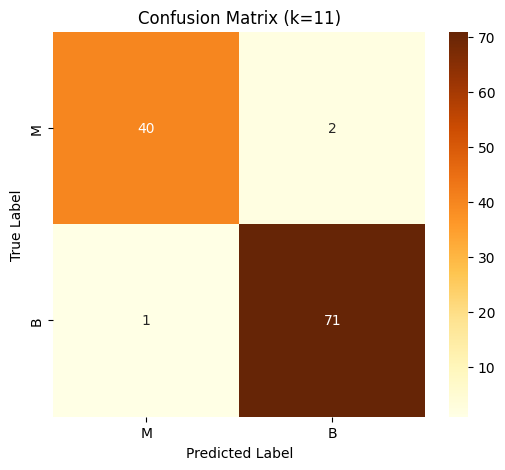

8. True Positive value: 40
9. Prediction for validation data 1: Malignant (M)
10. Prediction for validation data 2: Benign (B)


In [ ]:
cm = confusion_matrix(y_test, final_preds, labels=['M', 'B'])
true_positive = cm[0][0]

# Plot the Confusion Matrix
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=['M', 'B'], yticklabels=['M', 'B'])
plt.title(f'Confusion Matrix (k={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Predict on validation data
val_preds = final_model.predict(X_val)
val1 = 'Malignant (M)' if val_preds[0] == 'M' else 'Benign (B)'
val2 = 'Malignant (M)' if val_preds[1] == 'M' else 'Benign (B)'

print(f"8. True Positive value: {true_positive}")
print(f"9. Prediction for validation data 1: {val1}")
print(f"10. Prediction for validation data 2: {val2}")

As for the conclusion, it appears the model achieved a high accuracy of 97.37% with an optimal k-value of 11. The model predicted the first validation data point as Malignant and the second as Benign.